# Strides


We already know:

* filter scans the image
* feature maps are created

Now the next doubt:

> **Why did 28×28 become 26×26?**
> **How does the filter move?**
> **Can we control this?**

That is exactly what we solve now.

---

# 🎬 Chapter 4 — Stride and Padding in CNN

## 🎭 Characters

👩 **Riya**
👨‍🏫 **Professor Arjun**
🤖 **Milo**

---

# 🌅 Scene: The Shrinking Image Mystery

Riya looks confused.

> **Riya:** Sir… we gave a 28×28 image… but after convolution it became 26×26. Why did the image shrink??

Professor Arjun smiles.

> **Because of how the filter moves and because we didn’t protect the edges.**

Milo writes:

```text
Stride → how the filter moves
Padding → how we protect the edges
```

---

# 🧠 Step 1 — What is Stride?

Stride means:

```text
How many steps the filter moves each time
```

---

# 😄 Super simple intuition

Professor Arjun says:

> **Imagine you are walking on tiles.**
>
> If you move:
>
> * 1 tile at a time → slow and detailed
> * 2 tiles at a time → faster but you skip some places

That is exactly stride.

---

# 📊 Example

### Stride = 1

```text
Filter moves like:
→ one step right
→ one step right
→ next row
```

Covers almost every part of the image.

---

### Stride = 2

```text
Filter jumps:
→ skips one step
→ moves faster
```

Covers fewer positions.

---

# 🧠 Step 2 — Why stride matters

| Stride | Effect               |
| ------ | -------------------- |
| 1      | detailed scanning    |
| 2      | faster, less detail  |
| 3+     | very coarse scanning |

---

# 📊 Visual intuition

### Stride = 1

```text
[ ][ ][ ][ ]
[ ][ ][ ][ ]
[ ][ ][ ][ ]
```

Filter moves:

```text
→ → →
↓
→ → →
```

---

### Stride = 2

```text
→   →
    
→   →
```

Some positions are skipped.

---

# 🧠 Step 3 — What is Padding?

Now comes the second concept.

Padding means:

```text
Adding extra border around the image
```

---

# 😄 Funny intuition

Professor Arjun says:

> **Padding is like putting a cushion around your image so edges don’t get ignored.**

---

# 🧠 Why do we need padding?

Without padding:

* filter cannot fully cover edges
* output size becomes smaller

Example:

```text
28×28 → 26×26
```

Because filter cannot go outside the image.

---

# 📊 Example of Padding

Original image:

```text
[ 1 2 3 ]
[ 4 5 6 ]
[ 7 8 9 ]
```

After padding:

```text
[ 0 0 0 0 0 ]
[ 0 1 2 3 0 ]
[ 0 4 5 6 0 ]
[ 0 7 8 9 0 ]
[ 0 0 0 0 0 ]
```

We added zeros around.

---

# 🧠 Types of Padding

### 1️⃣ Valid Padding (No Padding)

```python
padding = "valid"
```

Means:

```text
No extra border
Output shrinks
```

---

### 2️⃣ Same Padding

```python
padding = "same"
```

Means:

```text
Output size stays same as input
```

---

# 🧠 Key idea

Milo writes:

```text
No padding → image shrinks
With padding → image size preserved
```

---

# 🧪 Hands-on Code — Stride and Padding


In [1]:


# 🧪 Step 1 — Import libraries


# Import tensorflow
import tensorflow as tf

# Import layers and model
from tensorflow.keras import layers, models

# Import matplotlib for visualization
import matplotlib.pyplot as plt



In [2]:


# 🧪 Step 2 — Load MNIST dataset

# Load handwritten digit dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


# 🧪 Step 3 — Normalize and reshape


In [3]:
# Normalize pixel values
x_train = x_train / 255.0

# Reshape to CNN format
x_train = x_train.reshape((60000, 28, 28, 1))

# 🧪 Step 4 — Take one sample image


In [4]:
# Select one image
sample_image = x_train[0:1]

# 🧪 Step 5 — Model with stride = 1


In [5]:

# Model with stride = 1 (default)
model_stride1 = models.Sequential()

model_stride1.add(
    layers.Conv2D(
        1,                # 1 filter
        (3, 3),           # filter size
        strides=(1, 1),   # stride = 1
        padding="valid",  # no padding
        activation="relu",
        input_shape=(28, 28, 1)
    )
)

C:\Users\Edunet Foundation\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)




# 🧪 Step 6 — Get output


In [6]:

# Pass image through model
output_stride1 = model_stride1.predict(sample_image)

# Print shape
print("Stride=1 output shape:", output_stride1.shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Stride=1 output shape: (1, 26, 26, 1)


```

Expected:

```text
(1, 26, 26, 1)
```

---

# 🧠 Why 26?

Simple formula idea:

```text
28 - 3 + 1 = 26
```

So output becomes smaller.

---

# 🧪 Step 7 — Model with stride = 2


In [7]:
# Model with stride = 2
model_stride2 = models.Sequential()

model_stride2.add(
    layers.Conv2D(
        1,
        (3, 3),
        strides=(2, 2),   # stride = 2
        padding="valid",
        activation="relu",
        input_shape=(28, 28, 1)
    )
)

# 🧪 Step 8 — Get output


In [8]:
# Pass image
output_stride2 = model_stride2.predict(sample_image)

# Print shape
print("Stride=2 output shape:", output_stride2.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Stride=2 output shape: (1, 13, 13, 1)




Expected:

```text
(1, 13, 13, 1)
```

---

# 🧠 Understanding

Because stride is bigger:

```text
Filter jumps → fewer steps → smaller output
```

---

# 🧪 Step 9 — Model with padding = "same"


In [9]:
# Model with SAME padding
model_padding_same = models.Sequential()

model_padding_same.add(
    layers.Conv2D(
        1,
        (3, 3),
        strides=(1, 1),
        padding="same",   # important
        activation="relu",
        input_shape=(28, 28, 1)
    )
)

# 🧪 Step 10 — Get output


In [10]:
# Pass image
output_same = model_padding_same.predict(sample_image)

# Print shape
print("Padding='same' output shape:", output_same.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Padding='same' output shape: (1, 28, 28, 1)




---


```

Expected:

```text
(1, 28, 28, 1)
```

---

# 🧠 Big learning moment

Professor Arjun explains:

> **With SAME padding, the output size stays the same.**

Because padding adds border pixels.

---


# 🧪 Step 11 — Visual comparison


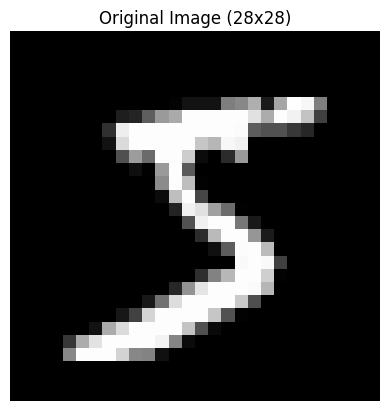

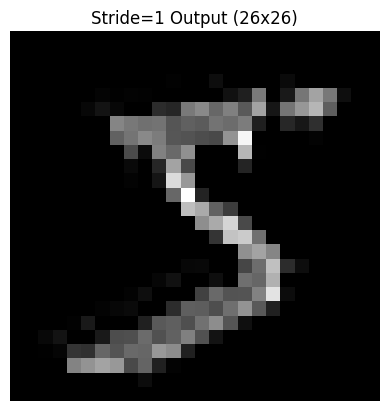

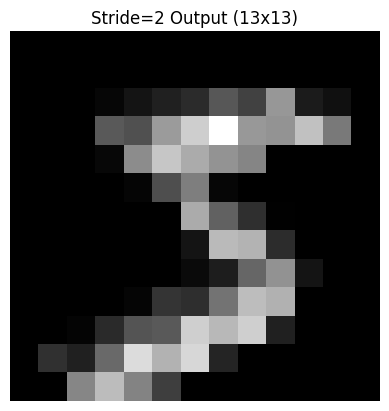

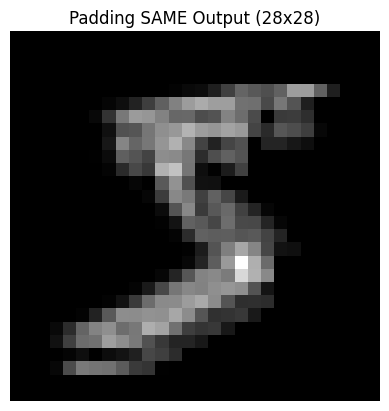

In [11]:
# Show original image
plt.imshow(sample_image[0, :, :, 0], cmap="gray")
plt.title("Original Image (28x28)")
plt.axis("off")
plt.show()

# Show stride=1 output
plt.imshow(output_stride1[0, :, :, 0], cmap="gray")
plt.title("Stride=1 Output (26x26)")
plt.axis("off")
plt.show()

# Show stride=2 output
plt.imshow(output_stride2[0, :, :, 0], cmap="gray")
plt.title("Stride=2 Output (13x13)")
plt.axis("off")
plt.show()

# Show padding same output
plt.imshow(output_same[0, :, :, 0], cmap="gray")
plt.title("Padding SAME Output (28x28)")
plt.axis("off")
plt.show()



```

---

# 🧠 What we will SEE

They will clearly observe:

| Case           | Output Size      |
| -------------- | ---------------- |
| stride=1       | slightly smaller |
| stride=2       | much smaller     |
| padding="same" | same size        |

This visual learning is VERY powerful.

---

# 🤖 Milo’s simple summary

```text
Stride = how far the filter moves each step
Padding = adding border to protect edges

Bigger stride → smaller output
No padding → image shrinks
Same padding → size stays same
```

---

# 📊 Final cheat table

| Concept       | Meaning             |
| ------------- | ------------------- |
| Stride        | step size of filter |
| Padding       | adding border       |
| valid padding | no border           |
| same padding  | keep size same      |

---



# 🧪 Practice

### Practice 1

```python
strides=(3,3)
```

Ask:

```text
What happens to output size?
```

---

### Practice 2

```python
padding="same"
```

Try with stride=2

Ask:

```text
Is size still same?
```

---

### Practice 3

Change filter size:

```python
(5,5)
```

Ask:

```text
Does output shrink more?
```

---


